In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="hXz3T5G8vJ6Ka9wW7331")
project = rf.workspace("roshan-patel-jsmlz").project("road-detection2-lwa3h")
version = project.version(5)
dataset = version.download("coco-segmentation")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Road-Detection2-5 in coco-segmentation:: 100%|██████████| 127/127 [00:00<00:00, 1851.40it/s]


In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# AM-UNet Architecture
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AMUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=4):
        super(AMUNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.down1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.down2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(128, 128, 64)
        self.up_conv1 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(64, 64, 32)
        self.up_conv2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder(x)
        e2 = self.down1(e1)
        e3 = self.down2(e2)

        d1 = self.up1(e3)
        a1 = self.att1(d1, e2)
        d1 = torch.cat((a1, d1), dim=1)
        d1 = self.up_conv1(d1)

        d2 = self.up2(d1)
        a2 = self.att2(d2, e1)
        d2 = torch.cat((a2, d2), dim=1)
        d2 = self.up_conv2(d2)

        out = self.final_conv(d2)
        return out

In [4]:
# Configurations
DATA_DIR = "/content/Road-Detection2-5"
TRAIN_ANNOTATION = os.path.join(DATA_DIR, "train", "_annotations.coco.json")
VALID_ANNOTATION = os.path.join(DATA_DIR, "valid", "_annotations.coco.json")
TEST_DIR = os.path.join(DATA_DIR, "test")
MODEL_SAVE_PATH = "road_classifier.pth"
CLASS_COLORS = {
    1: (255, 0, 0),   # Main Road - Red
    2: (0, 255, 0),   # Service Road - Green
    3: (0, 0, 255),   # Street Road - Blue
}

In [5]:
# Load and preprocess dataset
class RoadDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, annotation_file, transform=None):
        self.img_dir = img_dir
        self.coco = COCO(annotation_file)
        self.img_ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')

        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        for ann in anns:
            category_id = ann['category_id']
            mask = np.maximum(mask, (self.coco.annToMask(ann) * category_id))

        if self.transform:
            img = self.transform(img)
            mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask

In [6]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

In [7]:
# Load datasets
train_dataset = RoadDataset(os.path.join(DATA_DIR, "train"), TRAIN_ANNOTATION, transform)
valid_dataset = RoadDataset(os.path.join(DATA_DIR, "valid"), VALID_ANNOTATION, transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=4)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [8]:
# Model setup
model = AMUNet(in_channels=3, out_channels=4).cuda()

# Training loop
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [9]:
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for images, masks in train_loader:
        images, masks = images.cuda(), masks.cuda()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Save model
torch.save(model.state_dict(), MODEL_SAVE_PATH)

Epoch [1/100], Loss: 1.0917
Epoch [2/100], Loss: 0.3916
Epoch [3/100], Loss: 0.3732
Epoch [4/100], Loss: 0.2863
Epoch [5/100], Loss: 0.2928
Epoch [6/100], Loss: 0.2604
Epoch [7/100], Loss: 0.2237
Epoch [8/100], Loss: 0.2524
Epoch [9/100], Loss: 0.2763
Epoch [10/100], Loss: 0.2307
Epoch [11/100], Loss: 0.2405
Epoch [12/100], Loss: 0.1487
Epoch [13/100], Loss: 0.1730
Epoch [14/100], Loss: 0.1641
Epoch [15/100], Loss: 0.1985
Epoch [16/100], Loss: 0.2780
Epoch [17/100], Loss: 0.1744
Epoch [18/100], Loss: 0.1641
Epoch [19/100], Loss: 0.1961
Epoch [20/100], Loss: 0.1948
Epoch [21/100], Loss: 0.2396
Epoch [22/100], Loss: 0.2495
Epoch [23/100], Loss: 0.1967
Epoch [24/100], Loss: 0.1948
Epoch [25/100], Loss: 0.3048
Epoch [26/100], Loss: 0.1713
Epoch [27/100], Loss: 0.1741
Epoch [28/100], Loss: 0.1466
Epoch [29/100], Loss: 0.2153
Epoch [30/100], Loss: 0.2019
Epoch [31/100], Loss: 0.3071
Epoch [32/100], Loss: 0.1562
Epoch [33/100], Loss: 0.2045
Epoch [34/100], Loss: 0.2377
Epoch [35/100], Loss: 0

In [10]:
# Prediction and visualization
def predict_and_visualize(img_path, model, class_colors):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_resized = transform(img).unsqueeze(0).cuda()
    with torch.no_grad():
        output = model(img_resized).argmax(1).squeeze().cpu().numpy()

    mask = np.zeros((*output.shape, 3), dtype=np.uint8)
    for class_id, color in class_colors.items():
        mask[output == class_id] = color

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.show()


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


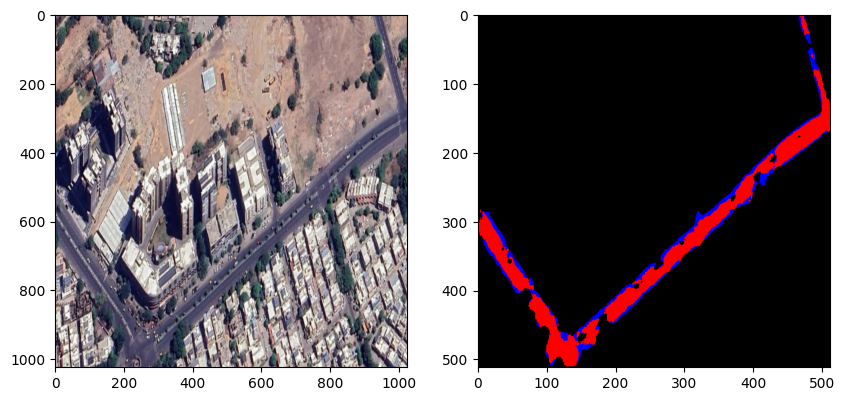

Road classification complete! 🚀


In [11]:
# Test prediction
test_image_path = os.path.join(TEST_DIR, "chunk_43_jpeg.rf.3fd3663d666340483b63b7ad065efbfc.jpg")  # Replace with your test image path
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
predict_and_visualize(test_image_path, model, CLASS_COLORS)

print("Road classification complete! 🚀")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


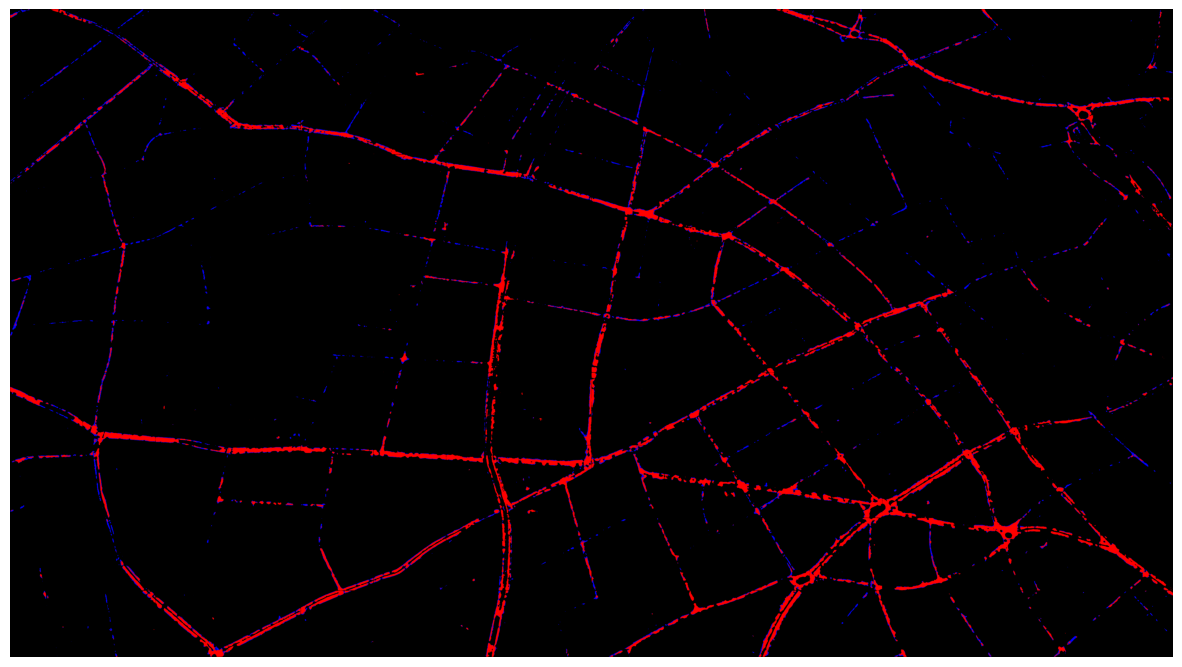

Road classification saved to output_mask.jpg
Road classification complete! 🚀


In [13]:
# Additional configurations for chunk processing
CHUNK_SIZE = 512

# Load model
def load_model(model_path):
    model = AMUNet(in_channels=3, out_channels=4)
    state_dict = torch.load(model_path)
    model.load_state_dict(state_dict)
    model = model.cuda()
    model.eval()
    return model

# Transformations
transform = transforms.Compose([
    transforms.Resize((CHUNK_SIZE, CHUNK_SIZE)),
    transforms.ToTensor()
])

# Split image into chunks dynamically
def split_image(img, chunk_size):
    h, w = img.shape[:2]
    rows = (h + chunk_size - 1) // chunk_size
    cols = (w + chunk_size - 1) // chunk_size
    chunks = []
    for i in range(rows):
        for j in range(cols):
            y_start, y_end = i * chunk_size, min((i + 1) * chunk_size, h)
            x_start, x_end = j * chunk_size, min((j + 1) * chunk_size, w)
            chunk = img[y_start:y_end, x_start:x_end]
            if chunk.size > 0:  # Avoid empty chunks
                chunks.append((chunk, (y_start, y_end, x_start, x_end)))
    return chunks

# Merge chunks back to original size
def merge_chunks(chunks, img_shape):
    merged_img = np.zeros((img_shape[0], img_shape[1], 3), dtype=np.uint8)
    for chunk, (y_start, y_end, x_start, x_end) in chunks:
        chunk_resized = cv2.resize(chunk, (x_end - x_start, y_end - y_start))
        merged_img[y_start:y_end, x_start:x_end] = chunk_resized
    return merged_img

# Predict mask for a single chunk
def predict_chunk(chunk, model):
    chunk_pil = Image.fromarray(chunk)
    img_resized = transform(chunk_pil).unsqueeze(0).cuda()
    with torch.no_grad():
        output = model(img_resized).argmax(1).squeeze().cpu().numpy()
    mask = np.zeros((CHUNK_SIZE, CHUNK_SIZE, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        mask[output == class_id] = color
    return mask

# Full prediction pipeline
def classify_whole_image(image_path, model_path, output_path):
    model = load_model(model_path)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_shape = img.shape

    chunks = split_image(img, CHUNK_SIZE)
    predicted_chunks = [(predict_chunk(chunk, model), coords) for chunk, coords in chunks]
    result_img = merge_chunks(predicted_chunks, img_shape)

    plt.figure(figsize=(15, 10))
    plt.imshow(result_img)
    plt.axis('off')
    plt.show()

    cv2.imwrite(output_path, cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))
    print(f"Road classification saved to {output_path}")

# Example usage
image_path = "/content/010.jpg"
model_path = "road_classifier.pth"
output_path = "output_mask.jpg"
classify_whole_image(image_path, model_path, output_path)

print("Road classification complete! 🚀")